In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [52]:
df = pd.read_excel('C:\\Users\\LENOVO\\Downloads\\khu lap trinh\\machine_learning\\ML_project\\data\\raw\\Pluvial_Flood_Dataset.xlsx')
display(df.head())

,X,Y,Slope,Curvature,Aspect,TWI,FA,Drainage,Rainfall,SUSCEP
0,3.909444,7.443056,46.686142,-3.888000e+09,45.000000,-3.250368,147.0,228.8528,101.515616,Very_High
1,3.908611,7.442778,52.151768,1.296000e+09,60.945396,-4.313832,61.0,229.6781,80.409863,Very_High
2,3.908889,7.442778,66.484085,0.000000e+00,67.619865,-8.327622,1.0,230.5920,78.986849,Very_High
3,3.909167,7.442778,58.007183,-2.592000e+09,38.659809,-4.707937,51.0,235.4210,81.953151,Very_High
4,3.909444,7.442778,60.503792,-1.296000e+09,351.869904,-5.985817,15.0,234.4346,85.866027,Very_High


In [53]:
print("Shape của dataset:", df.shape)
print("\nTên các cột:")
print(df.columns.tolist())
print("\n5 dòng đầu tiên:")
display(df.head())
print("\nThông tin tổng quát:")
print(df.info())

Shape của dataset: (144401, 10)

Tên các cột:
['X', 'Y', 'Slope', 'Curvature ', 'Aspect', 'TWI', 'FA', 'Drainage', 'Rainfall', 'SUSCEP']

5 dòng đầu tiên:


,X,Y,Slope,Curvature,Aspect,TWI,FA,Drainage,Rainfall,SUSCEP
0,3.909444,7.443056,46.686142,-3.888000e+09,45.000000,-3.250368,147.0,228.8528,101.515616,Very_High
1,3.908611,7.442778,52.151768,1.296000e+09,60.945396,-4.313832,61.0,229.6781,80.409863,Very_High
2,3.908889,7.442778,66.484085,0.000000e+00,67.619865,-8.327622,1.0,230.5920,78.986849,Very_High
3,3.909167,7.442778,58.007183,-2.592000e+09,38.659809,-4.707937,51.0,235.4210,81.953151,Very_High
4,3.909444,7.442778,60.503792,-1.296000e+09,351.869904,-5.985817,15.0,234.4346,85.866027,Very_High



Thông tin tổng quát:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144401 entries, 0 to 144400
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   X           144401 non-null  float64
 1   Y           144401 non-null  float64
 2   Slope       144119 non-null  float64
 3   Curvature   144401 non-null  float64
 4   Aspect      144401 non-null  float64
 5   TWI         144401 non-null  float64
 6   FA          144401 non-null  float64
 7   Drainage    144401 non-null  float64
 8   Rainfall    144401 non-null  float64
 9   SUSCEP      144401 non-null  object 
dtypes: float64(9), object(1)
memory usage: 11.0+ MB
None


In [54]:
df.columns = df.columns.str.strip()

In [55]:
print("Phân bố của target SUSCEP:")
print(df['SUSCEP'].value_counts())
print("\nTỷ lệ phần trăm:")
print(df['SUSCEP'].value_counts(normalize=True) * 100)

Phân bố của target SUSCEP:
SUSCEP
Moderate     38116
High         34451
Low          32252
Very_High    23456
No_Flood     16126
Name: count, dtype: int64

Tỷ lệ phần trăm:
SUSCEP
Moderate     26.395939
High         23.857868
Low          22.335025
Very_High    16.243655
No_Flood     11.167513
Name: proportion, dtype: float64


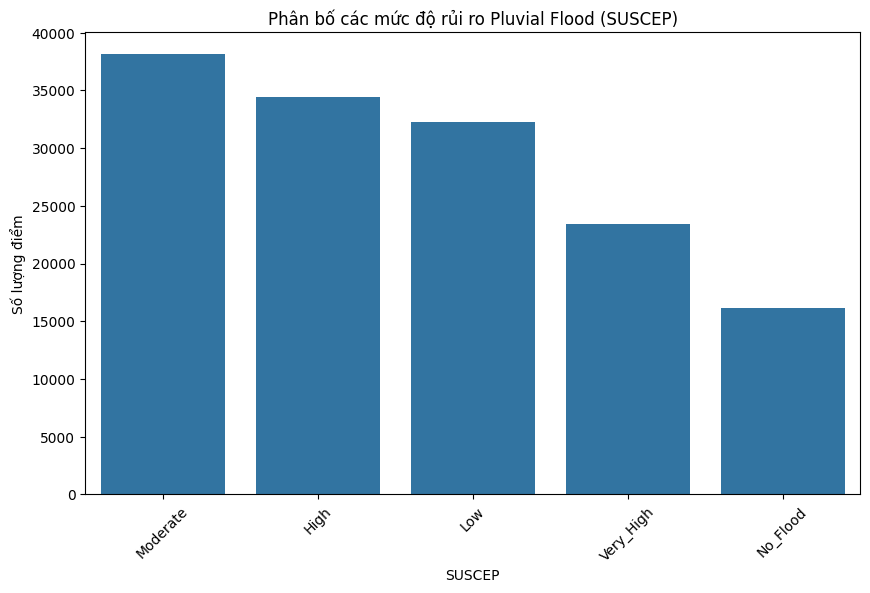

In [56]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='SUSCEP', order=df['SUSCEP'].value_counts().index)
plt.title('Phân bố các mức độ rủi ro Pluvial Flood (SUSCEP)')
plt.xticks(rotation=45)
plt.ylabel('Số lượng điểm')
plt.show()

In [57]:
print(df.isnull().sum())

X              0
Y              0
Slope        282
Curvature      0
Aspect         0
TWI            0
FA             0
Drainage       0
Rainfall       0
SUSCEP         0
dtype: int64


In [58]:
print(f"tỉ lệ missing của slope:{df['Slope'].isnull().sum() / len(df) * 100:.2f}%")

tỉ lệ missing của slope:0.20%


In [59]:
numeric_features = ['Slope', 'Curvature', 'Aspect', 'TWI', 'FA', 'Drainage', 'Rainfall']
display(df[numeric_features].describe().round(4))

,Slope,Curvature,Aspect,TWI,FA,Drainage,Rainfall
count,1.441190e+05,1.444010e+05,1.444010e+05,1.444010e+05,1.444010e+05,144401.0000,144401.0000
mean,-2.502788e+35,-8.342043e+35,-1.673122e+35,-2.120858e+34,-2.120858e+35,219.7145,74.7869
std,9.225150e+36,1.682769e+37,7.543591e+36,2.686356e+36,8.492619e+36,7.0579,8.8916
min,-3.402823e+38,-3.402823e+38,-3.402823e+38,-3.402823e+38,-3.402823e+38,203.7293,59.5411
25%,5.105760e+01,-2.592000e+09,1.013099e+02,-8.654600e+00,0.000000e+00,214.2869,68.1408
50%,6.198020e+01,0.000000e+00,1.894623e+02,-8.007000e+00,1.000000e+00,220.6313,73.8734
75%,6.916710e+01,2.592000e+09,2.700000e+02,-6.709300e+00,6.000000e+00,224.1914,81.3293
max,8.657540e+01,3.888000e+10,3.591449e+02,1.168340e+01,4.579360e+05,235.4210,101.5156


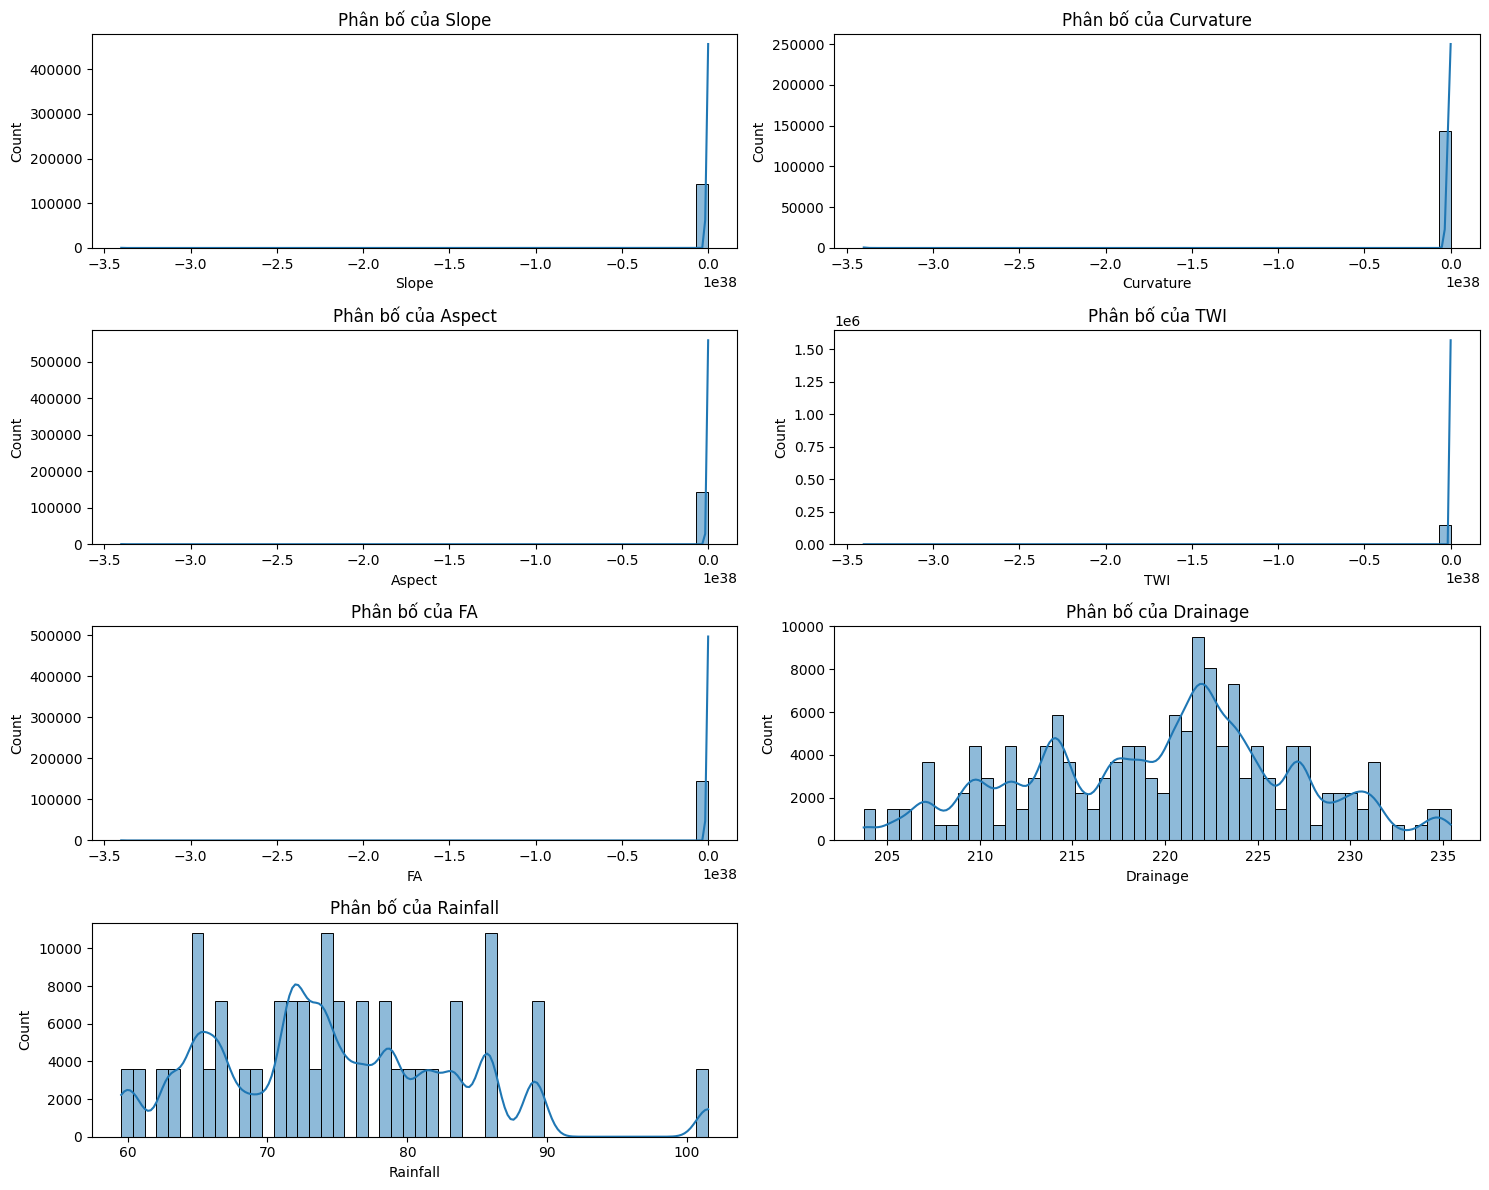

In [60]:
plt.figure(figsize=(15, 12))

for i, col in enumerate(numeric_features, 1):
    plt.subplot(4, 2, i)
    sns.histplot(df[col], kde=True, bins=50)
    plt.title(f'Phân bố của {col}')
    plt.xlabel(col)

plt.tight_layout()
plt.show()

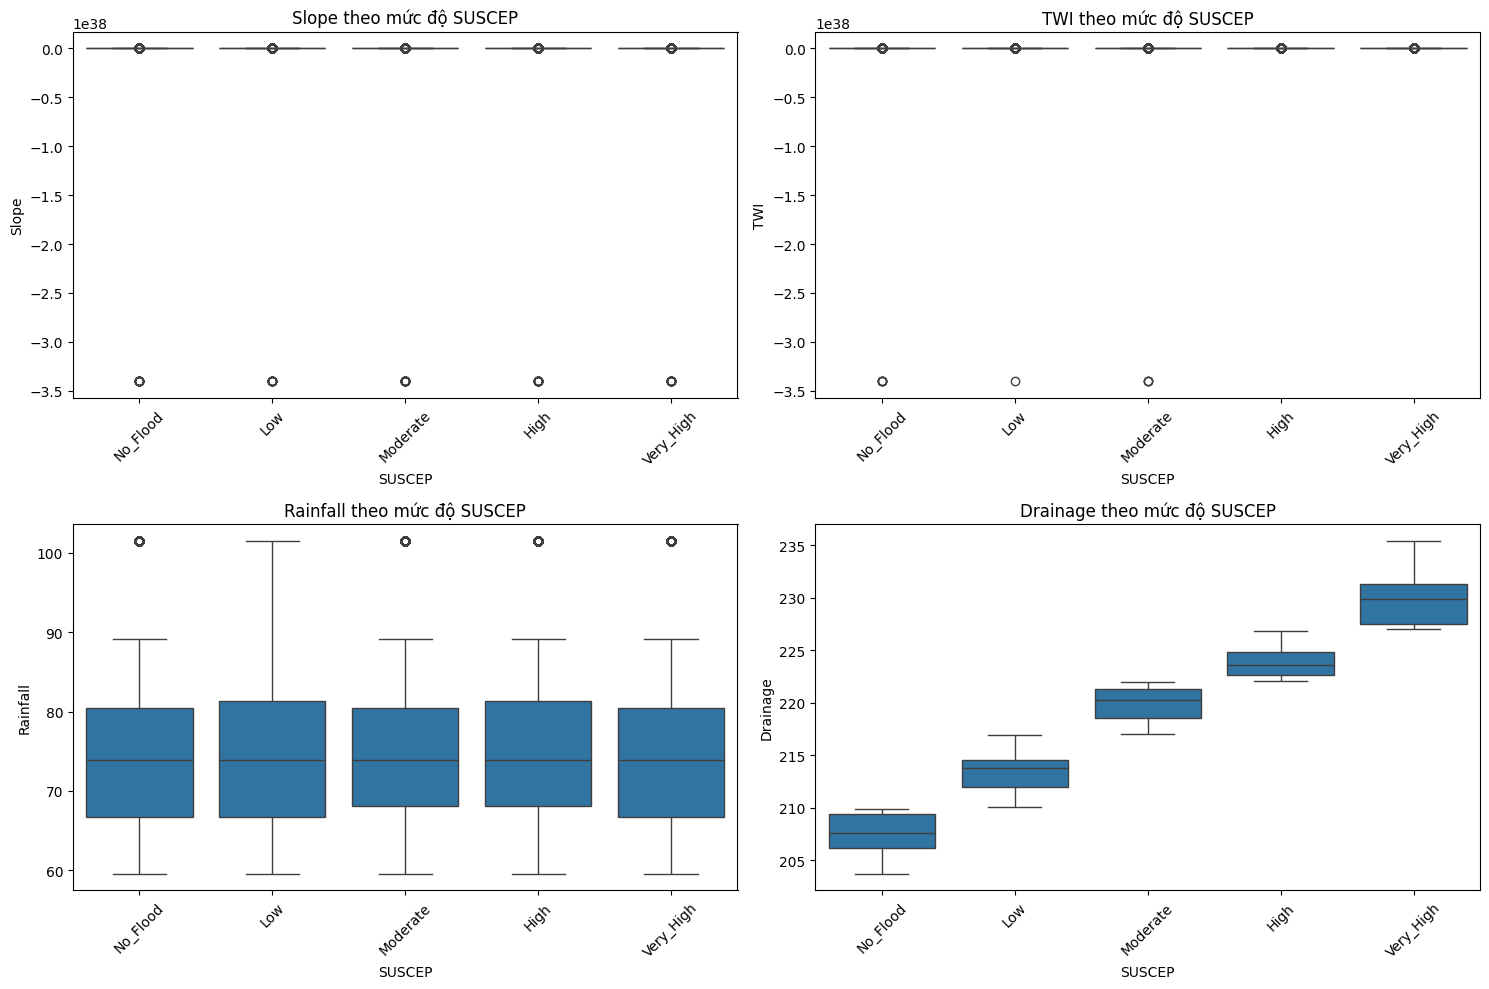

In [61]:
# 4. Boxplot so sánh features theo từng class của SUSCEP (để xem sự khác biệt)
plt.figure(figsize=(15, 10))
for i, col in enumerate(['Slope', 'TWI', 'Rainfall', 'Drainage'], 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df, x='SUSCEP', y=col, order=['No_Flood', 'Low', 'Moderate', 'High', 'Very_High'])
    plt.title(f'{col} theo mức độ SUSCEP')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [62]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['SUSCEP_encoded'] = le.fit_transform(df['SUSCEP'])


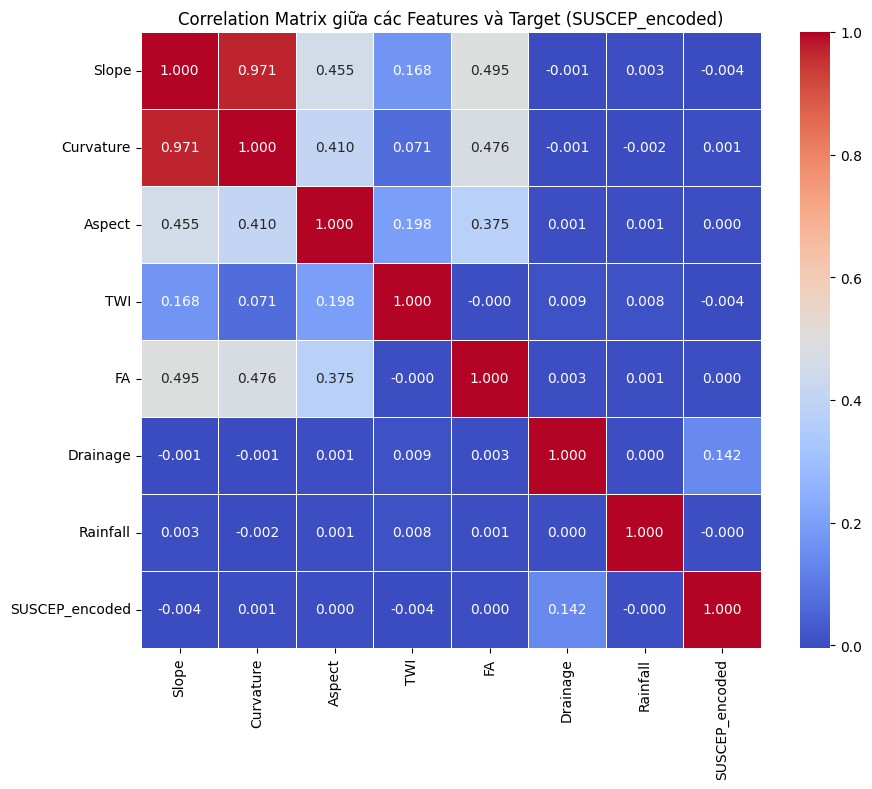

In [63]:
# 2. Correlation Matrix
plt.figure(figsize=(10, 8))
corr_matrix = df[numeric_features + ['SUSCEP_encoded']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.3f', linewidths=0.5)
plt.title('Correlation Matrix giữa các Features và Target (SUSCEP_encoded)')
plt.show()

*Ta đang có 2 pipeline*

TreePreProcess để dành cho các các thuật toán TreeBased

LinearPreProcess để dành cho các thuật toán cần sử dụng đến khoảng cách như LR, SVM, KNN

| Bước            | Pipeline A (Tree)        | Pipeline B (Linear/Distance) | Lý do khác nhau                              |
|-----------------|-------------------------|------------------------------|----------------------------------------------|
| Impute missing  | ✅ KNN Imputer          | ✅ KNN Imputer               | Cả 2 đều cần                                 |
| Clip outlier    | ✅ nhẹ (1%-99%)         | ✅ chặt hơn (5%-95%)         | Linear nhạy cảm hơn với outlier              |
| Fix skew        | ❌ không cần            | ✅ Yeo-Johnson               | Tree không quan tâm phân bố                 |
| Scale           | ❌ không cần            | ✅ RobustScaler              | Tree không dùng khoảng cách                 |
| Drop VIF        | ❌ không cần            | ✅ drop nếu VIF > 10         | Linear bị unstable với multicollinear       |


In [64]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [65]:
import importlib
import src.core.data_preprocessing as dp

importlib.reload(dp)

LinearPreprocessor = dp.LinearPreprocessor
TreePreprocessor = dp.TreePreprocessor

In [66]:
print(LinearPreprocessor.fit)

<function LinearPreprocessor.fit at 0x000001F10113A480>


In [67]:
train_df = pd.read_csv('C:\\Users\\LENOVO\\Downloads\\khu lap trinh\\machine_learning\\ML_project\\data\\splits\\train.csv')
train_df.columns = train_df.columns.str.strip()
print(train_df.columns.tolist())

['X', 'Y', 'Slope', 'Curvature', 'Aspect', 'TWI', 'FA', 'Drainage', 'Rainfall', 'SUSCEP']


In [68]:
tree_prep = TreePreprocessor()
train_tree = tree_prep.fit_transform(train_df)

linear_prep = LinearPreprocessor()
train_linear = linear_prep.fit_transform(train_df)

NUMERIC_COLS = ['Slope', 'Curvature', 'TWI', 'FA', 'Drainage', 'Rainfall']
# Chỉ lấy cols tồn tại trong cả 3 (linear có thể drop 1 col do VIF)
COMMON_COLS = [c for c in NUMERIC_COLS if c in train_linear.columns]

datasets = {
    'Raw'    : train_df[NUMERIC_COLS],
    'Tree'   : train_tree[NUMERIC_COLS],
    'Linear' : train_linear[COMMON_COLS],
}

colors = {'Raw': '#5B9BD5', 'Tree': '#70AD47', 'Linear': '#ED7D31'}


[TreePreprocessor] fitting on 101,080 rows...
[TreePreprocessor] fit done ✅

[LinearPreprocessor] fitting on 101,080 rows...
  Skew transforms:
    'Slope': skew=-0.834 → λ=2.4231
    'TWI': skew=1.170 → λ=-1.5698
    'FA': skew=3.007 → λ=-0.4755
    'Rainfall': skew=0.579 → λ=-0.8657
  VIF analysis:
    Drop 'TWI' (VIF=20.42)
    Features giữ lại: ['Slope', 'Curvature', 'Aspect_sin', 'Aspect_cos', 'FA', 'Drainage', 'Rainfall']
[LinearPreprocessor] fit done ✅


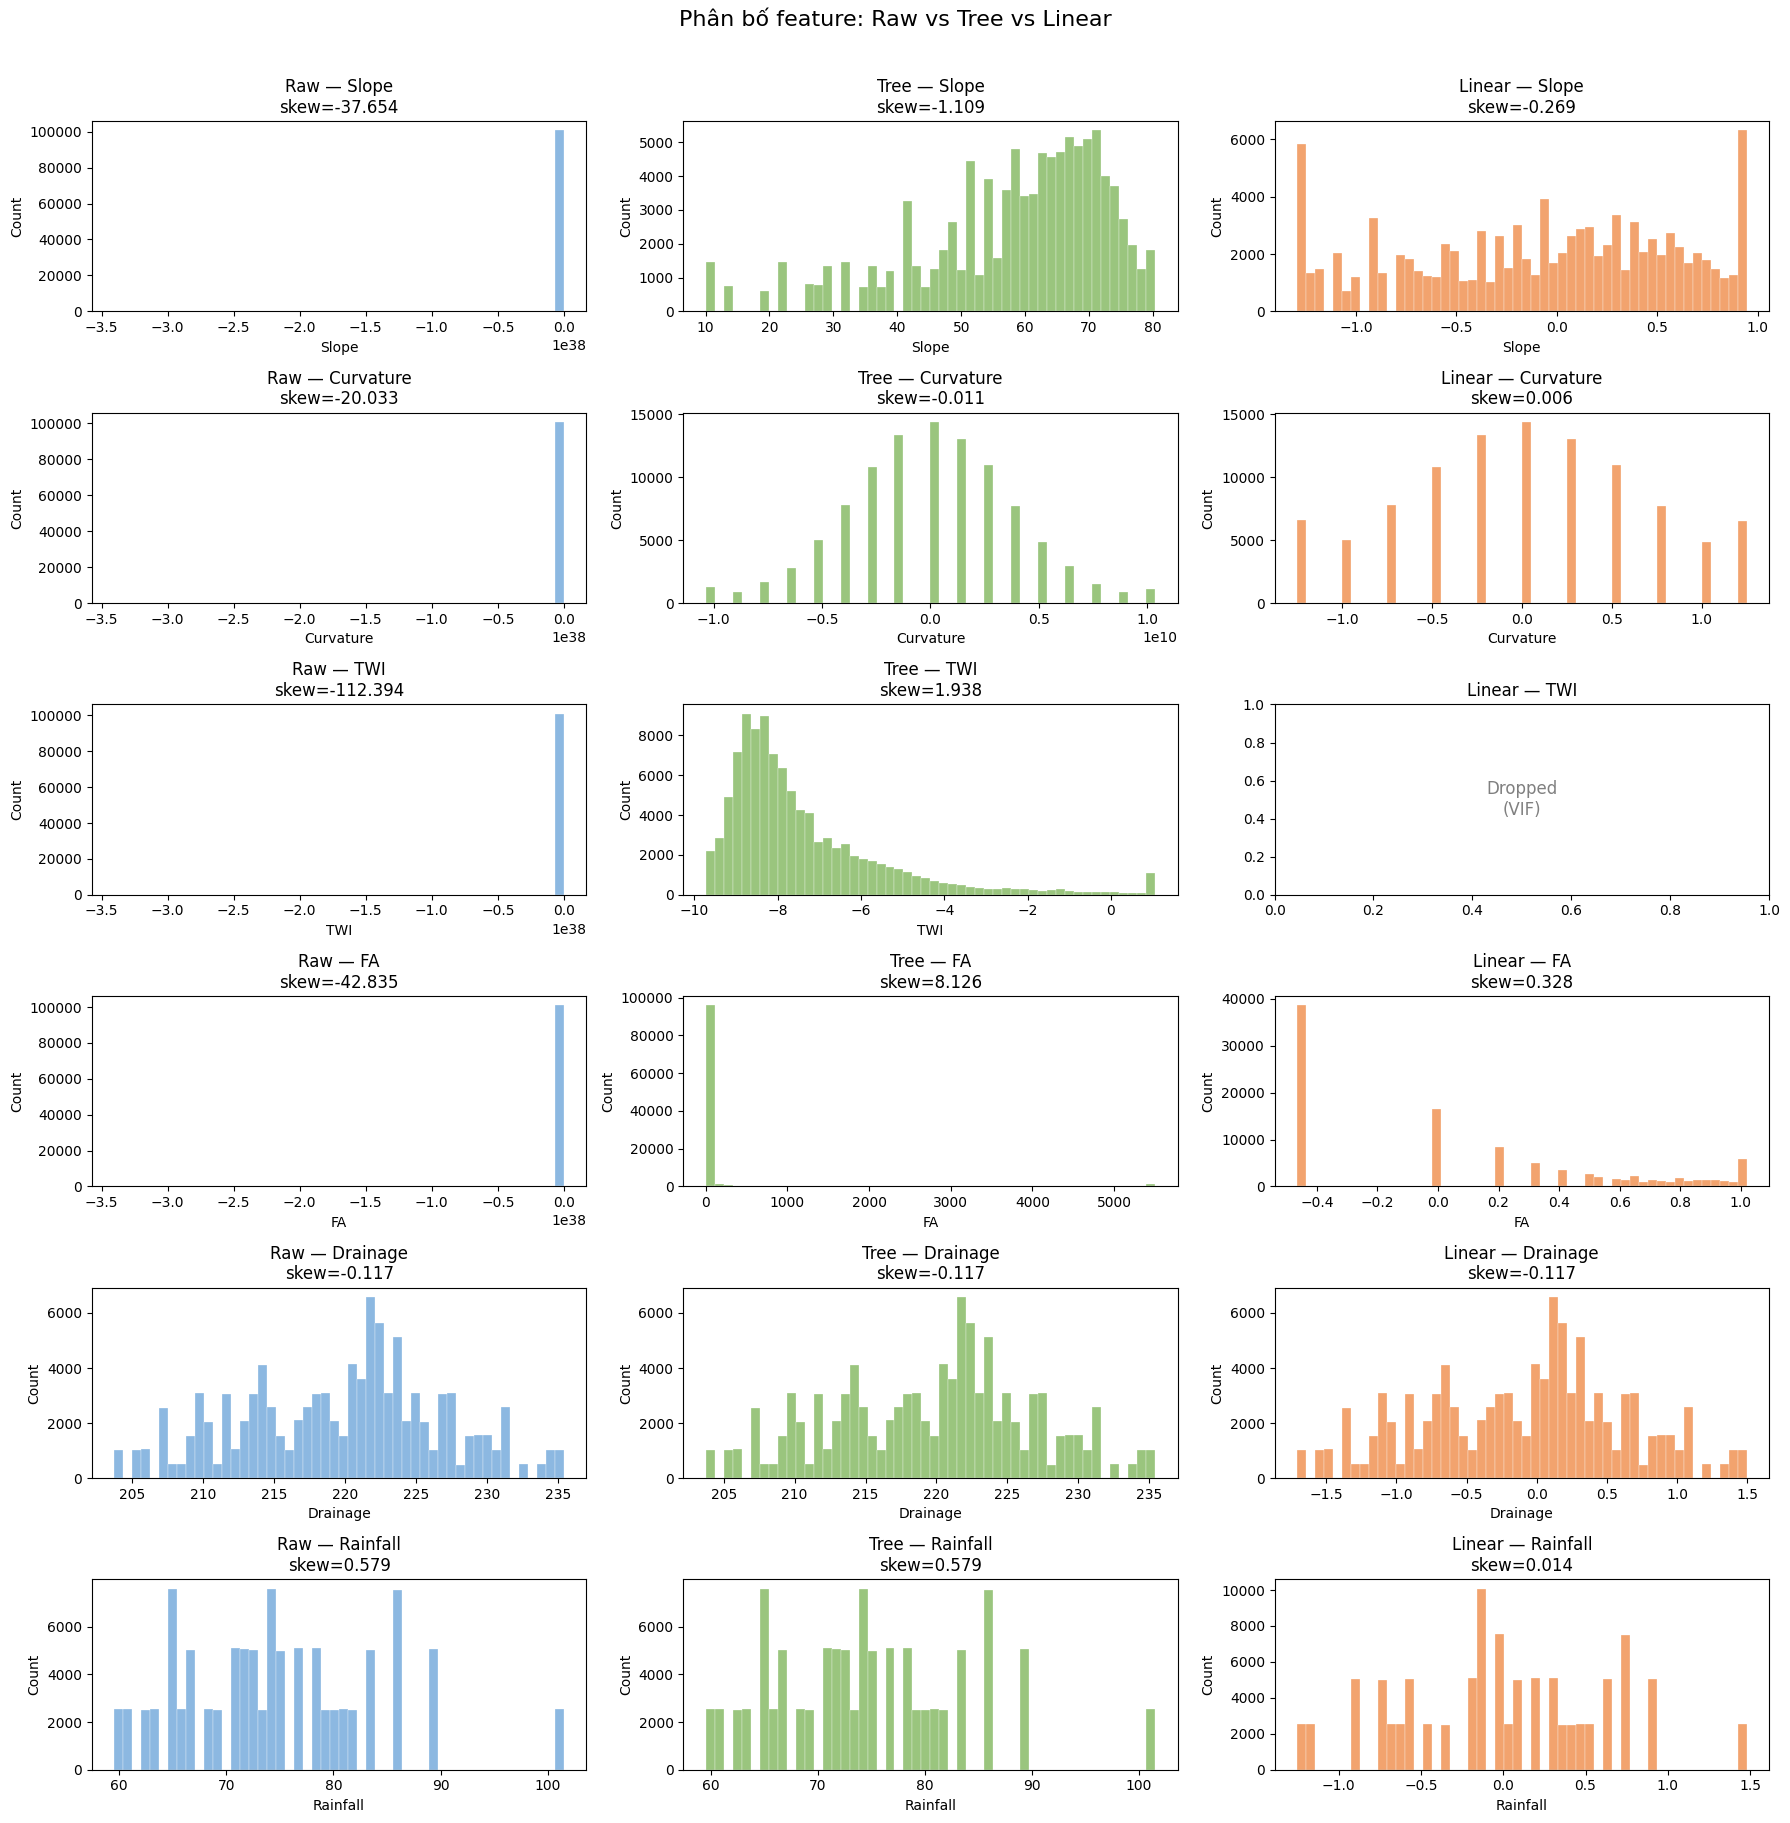

In [69]:
# ================================================================== #
# 3. HISTOGRAM — Phân bố từng feature
# ================================================================== #
fig, axes = plt.subplots(len(NUMERIC_COLS), 3, figsize=(18, len(NUMERIC_COLS) * 3))
fig.suptitle('Phân bố feature: Raw vs Tree vs Linear', fontsize=16, y=1.01)

for row, col in enumerate(NUMERIC_COLS):
    for ax_col, (name, data) in enumerate(datasets.items()):
        ax = axes[row, ax_col]
        if col not in data.columns:
            ax.text(0.5, 0.5, f'Dropped\n(VIF)', ha='center', va='center',
                    transform=ax.transAxes, fontsize=12, color='gray')
            ax.set_title(f'{name} — {col}')
            continue

        ax.hist(data[col].dropna(), bins=50, color=colors[name], 
                alpha=0.7, edgecolor='white', linewidth=0.3)
        skew = data[col].skew()
        ax.set_title(f'{name} — {col}\nskew={skew:.3f}')
        ax.set_xlabel(col)
        ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig('../experiments/figures/histogram_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

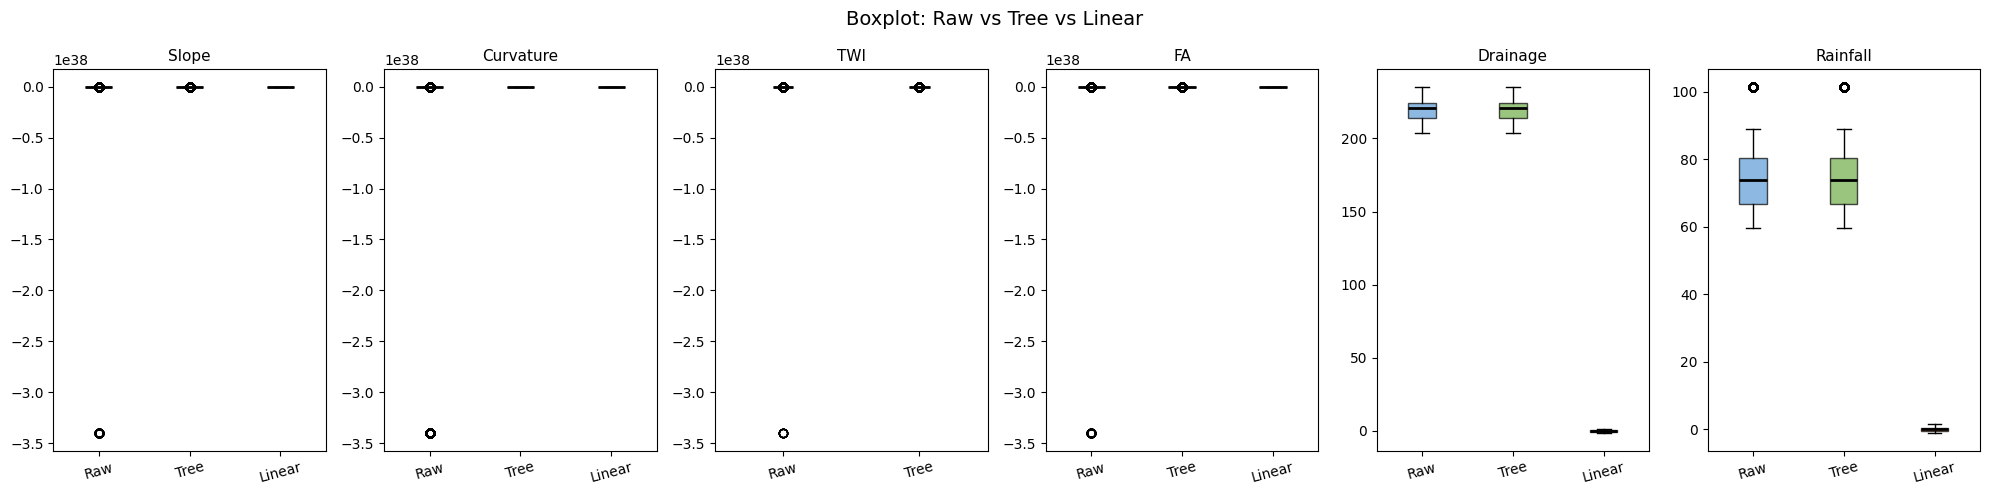

In [70]:
# ================================================================== #
# 4. BOXPLOT — So sánh outlier trước/sau
# ================================================================== #
fig, axes = plt.subplots(1, len(NUMERIC_COLS), figsize=(20, 5))
fig.suptitle('Boxplot: Raw vs Tree vs Linear', fontsize=14)

for ax, col in zip(axes, NUMERIC_COLS):
    plot_data = []
    plot_labels = []
    plot_colors = []

    for name, data in datasets.items():
        if col in data.columns:
            plot_data.append(data[col].dropna().values)
            plot_labels.append(name)
            plot_colors.append(colors[name])

    bp = ax.boxplot(plot_data, patch_artist=True, labels=plot_labels,
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], plot_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_title(col, fontsize=11)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../experiments/figures/boxplot_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

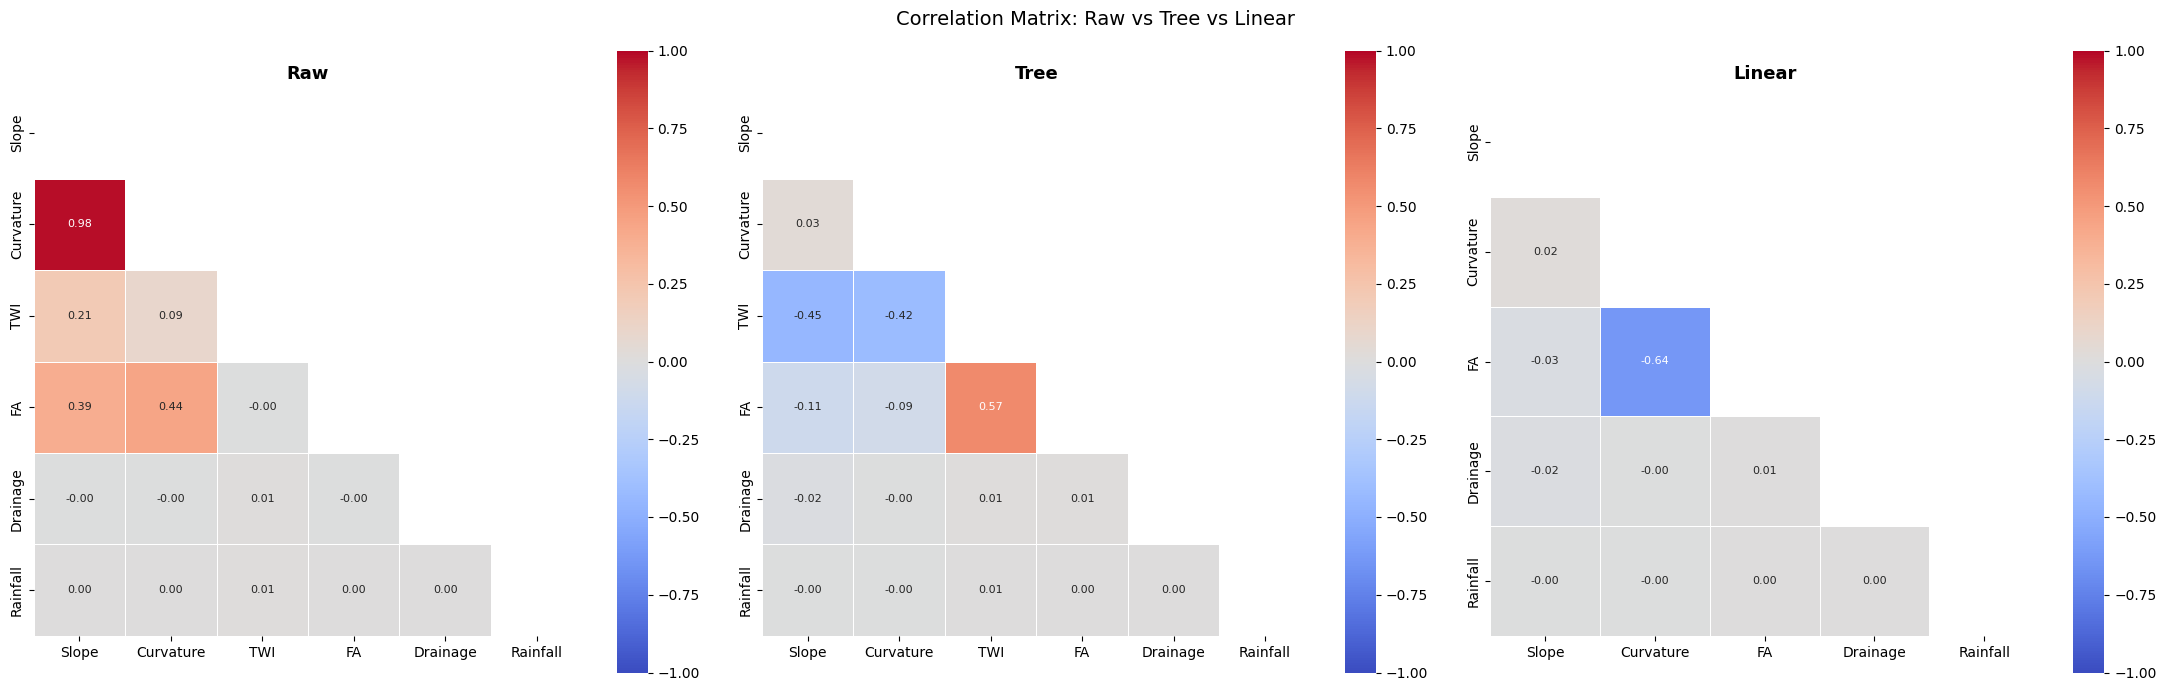

In [71]:
# ================================================================== #
# 5. CORRELATION MATRIX — So sánh 3 trường hợp
# ================================================================== #
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Correlation Matrix: Raw vs Tree vs Linear', fontsize=14)

for ax, (name, data) in zip(axes, datasets.items()):
    cols = [c for c in data.columns if c in NUMERIC_COLS]
    corr = data[cols].corr()

    mask = np.triu(np.ones_like(corr, dtype=bool))  # Chỉ hiện nửa dưới
    sns.heatmap(corr, ax=ax, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, vmin=-1, vmax=1, mask=mask,
                square=True, linewidths=0.5,
                annot_kws={'size': 8})
    ax.set_title(name, fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../experiments/figures/correlation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [72]:
# ================================================================== #
# 6. SKEWNESS TABLE — Số liệu cụ thể
# ================================================================== #
skew_data = {}
for name, data in datasets.items():
    skew_data[name] = {
        col: round(data[col].skew(), 3) if col in data.columns else 'Dropped'
        for col in NUMERIC_COLS
    }

skew_df = pd.DataFrame(skew_data)

# Highlight: |skew| > 1 là nặng, 0.5-1 là vừa
def highlight_skew(val):
    if val == 'Dropped':
        return 'background-color: #d3d3d3; color: gray'
    if abs(val) > 1:
        return 'background-color: #ff9999'  # Đỏ — skew nặng
    if abs(val) > 0.5:
        return 'background-color: #ffdd99'  # Vàng — skew vừa
    return 'background-color: #99dd99'      # Xanh — ổn

print("=== SKEWNESS TABLE ===")
display(skew_df.style.applymap(highlight_skew))

# Thêm stats tổng hợp
print("\n=== SUMMARY ===")
for name, data in datasets.items():
    cols = [c for c in NUMERIC_COLS if c in data.columns]
    skews = [abs(data[c].skew()) for c in cols]
    print(f"{name:8s} | mean |skew|={np.mean(skews):.3f} "
          f"| max |skew|={np.max(skews):.3f} "
          f"| cols kept={len(cols)}/{len(NUMERIC_COLS)}")


=== SKEWNESS TABLE ===


,Raw,Tree,Linear
Slope,-37.654000,-1.109000,-0.269000
Curvature,-20.033000,-0.011000,0.006000
TWI,-112.394000,1.938000,Dropped
FA,-42.835000,8.126000,0.328000
Drainage,-0.117000,-0.117000,-0.117000
Rainfall,0.579000,0.579000,0.014000



=== SUMMARY ===
Raw      | mean |skew|=35.602 | max |skew|=112.394 | cols kept=6/6
Tree     | mean |skew|=1.980 | max |skew|=8.126 | cols kept=6/6
Linear   | mean |skew|=0.147 | max |skew|=0.328 | cols kept=5/6


In [75]:
print(df[['X', 'Y', 'SUSCEP_encoded']].corr())

                       X         Y  SUSCEP_encoded
X               1.000000  0.129758        0.001111
Y               0.129758  1.000000        0.000391
SUSCEP_encoded  0.001111  0.000391        1.000000
